In [1]:
# Goal: determine quantity breaks to incentivize customers to purchase more of a product and increase revenue
# Changing the read_csv filename can allow this model to work with other csv files as long as the computer can find the path
# One other manual interaction is to use the elbow curve generated by the third cell to identify the optimal number of clusters
# Once the optimal number of clusters is known, the fourth cell has a parameter called num_clusters at the top to change.

In [2]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pandas import read_csv
from sklearn.decomposition import PCA
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from math import ceil
import ast

Check skewness and kurtosis of ['SalesQty', 'UnitPrice']
Skewness: [ 0.0854657  -0.00326747]
Kurtosis: [-1.15679211 -0.8156901 ]



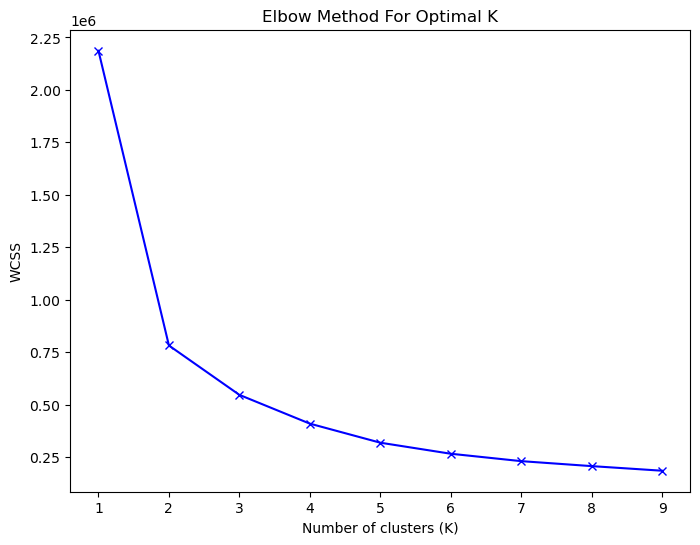

Use the elbow point from the above graph to set the num_clusters variable in the next cell.


In [3]:
# Use K-means clustering to identify similar products (segments)
# Start by identifying optimal number of clusters using the elbow point of elbow curve
# Preprossessing for the clusters involves using the box-cox transformation and scaling the features with the standard scaler

# define dataset
dataset = read_csv("Intuilize_SalesData_Comp1_QB.csv")

# ensure times are datetime and calculate recency
dataset['SalesDate'] = pd.to_datetime(dataset['SalesDate'])
most_recent = dataset['SalesDate'].max()
dataset['Recency'] = (most_recent - dataset['SalesDate']).dt.days

# # focus on data from the last 365 days
# within_time_frame = dataset.loc[dataset['Recency'] <= 365].copy()

# define product information based on the filtered data
columns_needed = ['SalesQty', 'UnitPrice', 'ProductID', 'Recency']
product_info = dataset[columns_needed].copy()

# drop rows with NaN values
sales_df = product_info.dropna()

# drop non-numerical data and handle negative values
numeric_columns = ['SalesQty', 'UnitPrice'] 
sales_df_numeric = sales_df[numeric_columns].copy()

# apply box-cox transformation to each column
for i in range(sales_df_numeric.shape[1]):
    if (sales_df_numeric.iloc[:, i] > 0).all(): 
        sales_df_numeric.iloc[:, i], _ = stats.boxcox(sales_df_numeric.iloc[:, i])

# scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(sales_df_numeric)
scaled_features = pd.DataFrame(scaled_features, columns=sales_df_numeric.columns)

# calculate and print skewness and kurtness to ensure K-Means clustering will work effectively
skewness = skew(scaled_features)
kurt = kurtosis(scaled_features)
print('Check skewness and kurtosis of', numeric_columns)
print('Skewness:', skewness)
print('Kurtosis:', kurt)
print()

# elbow method for K-means
wcss = []
K_range = range(1, 10) # number of clusters to check
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init=50)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
    
# plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal K')
plt.show()
print('Use the elbow point from the above graph to set the num_clusters variable in the next cell.')

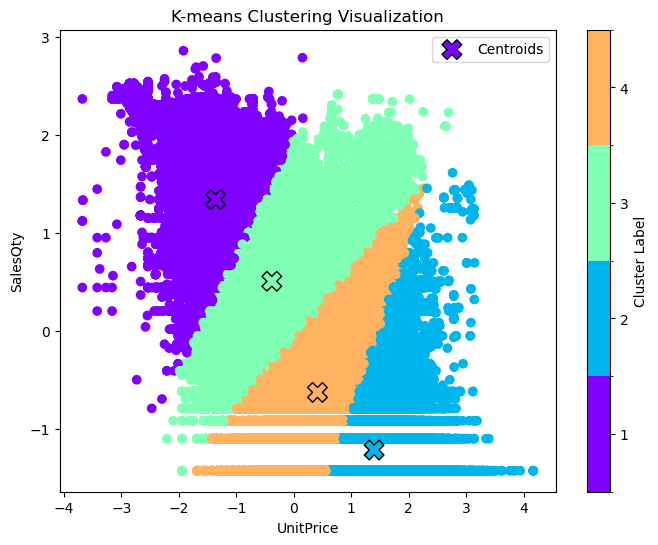

In [4]:
# Set num_clusters to the elbow point. Then, K-means clustering will identify similar products.
num_clusters = 4

# initialize KMeans
kmeans = KMeans(n_clusters=num_clusters, random_state=7, n_init=10)
kmeans.fit(scaled_features)

# retrieve the cluster labels
labels = kmeans.labels_

# add a label for the cluster ID to DataFrame, starting at 1
sales_df['ClusterID'] = labels + 1

# retrieve the cluster centers as a DataFrame
centers = pd.DataFrame(kmeans.cluster_centers_, columns=numeric_columns)

# create a discrete colormap with distinct colors for each cluster
cmap = plt.cm.rainbow(np.linspace(0, 1, num_clusters + 1))
custom_cmap = ListedColormap(cmap)

# define boundaries for each cluster
bounds = np.arange(1, num_clusters + 2) 
norm = BoundaryNorm(bounds, num_clusters)

# adjust labels to start from 1 instead of 0 on the graph
adjusted_labels = labels + 1
centroid_labels = np.arange(1, num_clusters + 1)

# visualize clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(scaled_features['UnitPrice'], scaled_features['SalesQty'], c=adjusted_labels, cmap=custom_cmap, norm=norm)
plt.scatter(centers['UnitPrice'], centers['SalesQty'], c=centroid_labels, cmap=custom_cmap, norm=norm, marker='X', s=200, edgecolor='black', label='Centroids')
plt.title('K-means Clustering Visualization')
plt.xlabel('UnitPrice')
plt.ylabel('SalesQty')

# create colorbar with the custom colormap
cbar = plt.colorbar(scatter, boundaries=bounds, ticks=range(1, num_clusters + 1))
cbar.set_label('Cluster Label')

# Adjust the legend and then show the graph
mid_ticks = (bounds[:-1] + bounds[1:]) / 2 
cbar.set_ticks(mid_ticks)
cbar.set_ticklabels(range(1, num_clusters + 1))
plt.legend(loc="upper right")
plt.show()

In [5]:
# Split data into quantiles (0-33%,34-66%,and 67%-99%) then train a RandomForestRegressor model
# This model will make predictions for all products

# focus on data from the last 365 days
within_time_frame = sales_df.loc[sales_df['Recency'] <= 365].copy()

# identify how many clusters (buckets of data) were used
num_clusters = int(sales_df['ClusterID'].max())

# create 3 buckets for each product using 3 quantiles
within_time_frame['small_quantile'] = within_time_frame.groupby('ProductID')['SalesQty'].transform(lambda x: x.quantile(0.33))
within_time_frame['medium_quantile'] = within_time_frame.groupby('ProductID')['SalesQty'].transform(lambda x: x.quantile(0.66))
within_time_frame['large_quantile'] = within_time_frame.groupby('ProductID')['SalesQty'].transform(lambda x: x.max())

# create an empty dataframe to store the predicted quantity breaks
quantity_break_columns = ['ProductID', 'SalesQty', 'UnitPrice']
quantity_breaks = pd.DataFrame(columns=quantity_break_columns)

# train separate models for each cluster
for cluster in range(1, num_clusters + 1):
    current_cluster = within_time_frame[within_time_frame['ClusterID'] == cluster].copy()
    
     # Split data into training and testing sets
    X = current_cluster[['SalesQty', 'UnitPrice']]
    y = current_cluster[['small_quantile','medium_quantile','large_quantile']]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train regressor model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    multi_rf_model = MultiOutputRegressor(rf_model)
    multi_rf_model.fit(X_train, y_train)

    # Predict and Evaluate for Each Quantity Break
    y_pred = multi_rf_model.predict(X_test)
    
    # Calculate evaluation metrics for each quantity break target
    for i, target in enumerate(['small_quantile', 'medium_quantile', 'large_quantile']):
        print(f"\nEvaluation for Cluster {cluster}, {target}:")
        print("Mean Absolute Error (MAE):", mean_absolute_error(y_test[target], y_pred[:, i]))
        print("Mean Squared Error (MSE):", mean_squared_error(y_test[target], y_pred[:, i]))
        print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test[target], y_pred[:, i])))
        print("R^2 Score:", r2_score(y_test[target], y_pred[:, i]))
        print()

    # Narrow down the entire cluster to 'ProductID', 'SalesQty', 'UnitPrice'
    entire_cluster = sales_df[sales_df['ClusterID'] == cluster].copy()
    entire_cluster = entire_cluster[['ProductID', 'SalesQty', 'UnitPrice']]
    
    # Make prediction for the entire cluster
    y_pred_full = multi_rf_model.predict(entire_cluster[['SalesQty', 'UnitPrice']])
    
    # append the predictions to the quantity break DataFrame
    entire_cluster[['small_break', 'medium_break', 'large_break']] = y_pred_full
    quantity_breaks = pd.concat([quantity_breaks, entire_cluster], ignore_index=True)

# average the predictions for each product to avoid repeats
quantity_breaks = quantity_breaks.groupby('ProductID').mean()
    
# print out a few quantity breaks
print('First 5 quantity breaks created by the Quantile model:')
print(quantity_breaks.head())


Evaluation for Cluster 1, small_quantile:
Mean Absolute Error (MAE): 291.8875743210324
Mean Squared Error (MSE): 6975094.614431918
Root Mean Squared Error (RMSE): 2641.0404416502065
R^2 Score: 0.95999780038117


Evaluation for Cluster 1, medium_quantile:
Mean Absolute Error (MAE): 446.881258683583
Mean Squared Error (MSE): 13057836.076477041
Root Mean Squared Error (RMSE): 3613.5627954246265
R^2 Score: 0.9453942138878596


Evaluation for Cluster 1, large_quantile:
Mean Absolute Error (MAE): 1869.1042499759951
Mean Squared Error (MSE): 115243397.00263423
Root Mean Squared Error (RMSE): 10735.147740140059
R^2 Score: 0.955113669159955


Evaluation for Cluster 2, small_quantile:
Mean Absolute Error (MAE): 0.6827580605351089
Mean Squared Error (MSE): 123.24753745974918
Root Mean Squared Error (RMSE): 11.101690747798246
R^2 Score: 0.6498504837457352


Evaluation for Cluster 2, medium_quantile:
Mean Absolute Error (MAE): 1.4499593617370103
Mean Squared Error (MSE): 1085.7474044846697
Root Me

In [6]:
# Train a decision tree model (DecisionTreeRegressor)
# This model might not have enough data to make a prediction for every product
# However, it will be able to provide more than 3 quantity break thresholds if there is enough data for the current product

# Calculate frequency by counting occurrences for each ProductID
frequency_df = sales_df.groupby('ProductID').size().reset_index(name='Frequency')
sales_df = sales_df.merge(frequency_df, on='ProductID')

# identify products that have enough data
quantity_break_products = sales_df[sales_df['Frequency'] >= 15]

# Dictionary to store optimal break points for each ProductID
optimal_breaks = {}

# Iterate over each ProductID that needs a quantity break
for product_id in quantity_break_products['ProductID'].unique():
    # Filter data for the specific ProductID
    product_sales_data = sales_df[sales_df['ProductID'] == product_id]
    
    # Ensure data is sorted by SalesQty
    product_sales_data = product_sales_data[['SalesQty', 'UnitPrice']].sort_values(by='SalesQty')
    
    # Define SalesQty as the feature and ExtPrice as the target
    X = product_sales_data[['SalesQty']]
    y = product_sales_data['UnitPrice']
    
    # Train a Decision Tree Regressor (max_depth affects the number of quantity threshholds)
    tree = DecisionTreeRegressor(max_depth=4) 
    tree.fit(X, y)
    
    # Extract the split points (quantity breaks) from the decision tree  
    # After training, the code retrieves the split points (thresholds) from the tree,
    # which indicates potential quantity breaks. Any split points that don’t create a split are removed (threshold != -2).
    break_points = sorted(tree.tree_.threshold[tree.tree_.threshold != -2].tolist())

    # Store the sorted break points for this ProductID if there is 3 or more quantity break thresholds
    if len(break_points) > 2:
        break_points = [int(ceil(x)) for x in break_points]
        optimal_breaks[product_id] = break_points

# Convert the optimal breaks dictionary to a DataFrame
tree_breaks_df = pd.DataFrame([{'ProductID': product_id, 'QuantityBreaks': breaks} 
                          for product_id, breaks in optimal_breaks.items()])

In [7]:
# Combine the quantile model and the decision tree model
# The decision tree quantity breaks will be favored as they provide more quantity break thresholds

# average the predictions for each product to avoid repeats
quantity_breaks = quantity_breaks.groupby('ProductID').mean()

# quantity_breaks covers all the products, and was created by the quantile model
# tree_breaks_df only covers products that had enough data to create a decision tree with 3 or more nodes
# combining them requires them to be in the same format
quantity_breaks['QuantityBreaks'] = quantity_breaks.apply(lambda row: f"[{row['small_break']}, {row['medium_break']}, {row['large_break']}]", axis=1)

# Merge the two the quantity breaks from the quantile model and the decision tree
combined_df = pd.merge(quantity_breaks, tree_breaks_df, on='ProductID', how='left', suffixes=('_quantile', '_tree'))

# # Update values in combined DataFrame with values from decision tree modeel where product ids match
combined_df['QuantityBreaks'] = combined_df['QuantityBreaks_tree'].fillna(combined_df['QuantityBreaks_quantile'])

# Drop the extra columns
combined_df = combined_df.drop(columns=['QuantityBreaks_quantile', 'QuantityBreaks_tree','small_break', 'medium_break', 'large_break'])

In [8]:
# Apply patches to overwrite quantity breaks that have quantity thresholds of 1
# Only apply a patch if a UnitPrice is within a percentage

# Define how close the UnitPrice needs to be to patch
percentage_threshold = 0.05

# Convert stringified lists to actual Python lists
def to_list(val):
    try:
        # Attempt to convert to a list
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        # If conversion fails, return the original value or a default
        return val
combined_df['QuantityBreaks'] = combined_df['QuantityBreaks'].apply(to_list)

# Filter rows that have a 1 as part of the quantity break
to_be_replaced = combined_df[combined_df['QuantityBreaks'].apply(lambda x: 1 in x)]

# identify quantity breaks that can be copied (opposite of to_be_replaced, no rows with 1 as part of quantity break)
replacement_candidates = combined_df[~combined_df['QuantityBreaks'].apply(lambda x: 1 in x)]

# Find closest rows for each UnitPrice in to_be_replaced, but only replace if within (+ or -) the percentage_threshold
for idx, row in to_be_replaced.iterrows():    
    target_value = row['UnitPrice']
    lower_bound = target_value * (1 - percentage_threshold)
    upper_bound = target_value * (1 + percentage_threshold)
    
    # Filter replacement_candidates for UnitPrice within the range
    potential_matches = replacement_candidates[
        (replacement_candidates['UnitPrice'] >= lower_bound) & 
        (replacement_candidates['UnitPrice'] <= upper_bound)
    ].copy()
    
    if not potential_matches.empty:
        # Find the closest match
        potential_matches['diff'] = (potential_matches['UnitPrice'] - target_value).abs()
        closest_row = potential_matches.loc[potential_matches['diff'].idxmin()]
        
        # Replace only the 'QuantityBreaks' column in to_be_replaced
        to_be_replaced.at[idx, 'QuantityBreaks'] = closest_row['QuantityBreaks']

# Drop the temporary 'diff' column if created
replacement_candidates = replacement_candidates.drop(columns=['diff'], errors='ignore')

# Update the original combined_df with the new replaced values
combined_df.update(to_be_replaced)

In [9]:
# Calculate a discount for the UnitPrice at each quantity threshold
base_price_increase = 0.05
discount_percentage = 0.02

# calculate average UnitCost from original dataset
costs = dataset.groupby('ProductID').agg({
        'UnitCost': 'mean'
    }).reset_index()

# Add the UnitCost column to the combined_df
if 'UnitCost' not in combined_df.columns:
    combined_df = pd.merge(combined_df, costs, on='ProductID')

# identify products where the cost is higher than the price
no_discounts = combined_df[combined_df['UnitCost'] >= combined_df['UnitPrice']].copy()

# exclude the products that should not get a discount
yes_discounts = combined_df[combined_df['UnitCost'] < combined_df['UnitPrice']].copy()

# Add 1 to the QuantityBreaks list if it's not already there
yes_discounts['QuantityBreaks'] = yes_discounts['QuantityBreaks'].apply(
    lambda x: [1] + [val for val in x if val != 1]
)

# Explode the QuantityBreaks column to get a row for each quantity break threshold
df_exploded = yes_discounts.explode('QuantityBreaks')

# Round the salesQty required for a quantity break to the nearest integer
df_exploded['QuantityBreaks'] = pd.to_numeric(df_exploded['QuantityBreaks'], errors='coerce')
df_exploded['QuantityBreaks'] = df_exploded['QuantityBreaks'].round(0).astype(int)

# Increase the base price slightly to encourage further sales and decrease the loss of profit caused by offering a discount
df_exploded['NewBasePrice'] = df_exploded['UnitPrice'] * (1 + base_price_increase)

# Create a new 'discount' column that applies the discount to the UnitCost
# Each row now corresponds to a specific tier, so we can apply the discount on the cost
df_exploded['Discount'] = df_exploded.groupby(['ProductID','NewBasePrice']).cumcount()  * discount_percentage
df_exploded['DiscountedPrice'] = df_exploded['NewBasePrice'] * (1 - df_exploded['Discount'])

# aggregate the results using .last()
df_result = df_exploded.groupby(['ProductID', 'UnitPrice', 'QuantityBreaks'], as_index=False)['DiscountedPrice'].last()

print('File saved to: CombinedModelQuantityBreaks.csv')
df_result.to_csv('CombinedModelQuantityBreaks.csv', index=False)

File saved to: CombinedModelQuantityBreaks.csv


In [10]:
# Simulate the results of the model using the sales data.
# An assumption for this simulation is that a customer would be willing to increase their puchase amount 
    # if they were close to the next quantity break threshold

# use original dataset to simulate results
original_dataset = read_csv("Intuilize_SalesData_Comp1_QB.csv")
    
# ensure times are datetime and calculate recency
original_dataset['SalesDate'] = pd.to_datetime(original_dataset['SalesDate'])
most_recent = original_dataset['SalesDate'].max()
original_dataset['Recency'] = (most_recent - original_dataset['SalesDate']).dt.days

# focus on data from the last 365 days
within_time_frame = original_dataset.loc[original_dataset['Recency'] <= 365].copy()

# drop columns that aren't needed
within_time_frame = within_time_frame.drop(columns=['BranchCode','LocationCode','CustomerID','SalesPersonID','ProductGroupID','OrderNumber','InvoiceNumber','LineNumber','OrderDate'])

# Use df_result from the previous cell to obtain quantity breaks
Quantity_break_info = df_result.copy()
QB_threshholds = Quantity_break_info.groupby('ProductID')['QuantityBreaks'].apply(list).reset_index()
QB_discounts = Quantity_break_info.groupby('ProductID')['DiscountedPrice'].apply(list).reset_index()

# Merge the DataFrames on 'product'
merged_df = pd.merge(within_time_frame, QB_threshholds, on='ProductID', how='left')
merged_df = pd.merge(merged_df, QB_discounts, on='ProductID', how='left')

# Add columns for original revenue and simulated revenue
merged_df['original_revenue'] = merged_df['UnitPrice'] * merged_df['SalesQty']
merged_df['simulated_revenue'] = merged_df['original_revenue']
merged_df = merged_df.dropna()

# Iterate through each row to simulate new revenue
for index, row in merged_df.iterrows():
    amount = row['SalesQty']
    price = row['UnitPrice']
    thresholds = row['QuantityBreaks']
    discounted_prices = row['DiscountedPrice']
    
    # Check each threshold to see if the customer is close enough to bump up
    for i, threshold in enumerate(thresholds):
        if amount < threshold and amount >= threshold * 0.95:
            # Bump up to the threshold and apply the discounted price
            new_price = discounted_prices[i]
            merged_df.at[index, 'simulated_revenue'] = threshold * new_price
            break

# Calculate total original revenue and total simulated revenue
total_original_revenue = merged_df['original_revenue'].sum()
total_simulated_revenue = merged_df['simulated_revenue'].sum()

# Calculate the percentage increase in revenue
percentage_increase = ((total_simulated_revenue - total_original_revenue) / total_original_revenue) * 100

# Display results
print(f"Percentage increase in revenue: {percentage_increase:.2f}%")
print()
print("Updated DataFrame with simulation details:")
print(merged_df[['ProductID', 'original_revenue', 'simulated_revenue']])

Percentage increase in revenue: -1.31%

Updated DataFrame with simulation details:
        ProductID  original_revenue  simulated_revenue
0           PROD1            666.04         666.040000
1           PROD2            160.00         162.187614
2           PROD2            160.00         162.187614
3           PROD2            160.00         162.187614
4           PROD2            160.00         162.187614
...           ...               ...                ...
360568  PROD28478             55.13          55.130000
360569  PROD28478             55.13          55.130000
360570  PROD28478             55.13          55.130000
360571  PROD28478            110.25         110.250000
360572   PROD7302            780.00         780.000000

[354705 rows x 3 columns]
